# TikTok and Snapchat Business Analysis

**Authors:** Aya Abdine, Meriam El Askri, and Ghofran Mahmoud

This portfolio notebook compares TikTok and Snapchat as digital business platforms. The original research focus is preserved: how engagement, platform usage, advertising logic, and innovation shape business value. The analysis avoids circular modeling by treating TikTok engagement rate as a constructed descriptive metric, not as an outcome to be predicted by the same variables that define it.

## 1. Project Overview

The project uses two datasets:

- `tiktok_dataset.csv`: video-level TikTok engagement data.
- `social_media_usage.csv`: user-level social media usage data from multiple apps.

Because the TikTok file is much more detailed than the Snapchat comparison file, TikTok receives deeper content-level analysis. The platform comparison is limited to the shared usage variables available for both platforms.

## 2. Imports and Setup

This cell imports the analysis libraries and creates folders for regenerated outputs.

In [1]:
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "analysis_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CLEAN_DIR = OUTPUT_DIR / "cleaned_data"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, CLEAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

## 3. Data Loading

The raw files are loaded directly from the project folder so the notebook can be rerun from a clean kernel.

In [2]:
tiktok_raw = pd.read_csv(ROOT / "tiktok_dataset.csv")
usage_raw = pd.read_csv(ROOT / "social_media_usage.csv")

print("TikTok raw shape:", tiktok_raw.shape)
print("Usage raw shape:", usage_raw.shape)

TikTok raw shape: (19382, 12)
Usage raw shape: (1000, 6)


## 4. Data Cleaning

Cleaning checks missing values, removes duplicates, standardizes categories, validates numeric ranges, and creates engagement-rate measures. The usage dataset is then filtered to TikTok and Snapchat for the platform comparison; rows from other apps are excluded from that comparison, not treated as invalid.

In [3]:
tiktok_required = [
    "claim_status", "verified_status", "author_ban_status",
    "video_duration_sec", "video_view_count", "video_like_count",
    "video_share_count", "video_download_count", "video_comment_count",
]

usage_required = [
    "App", "Daily_Minutes_Spent", "Posts_Per_Day",
    "Likes_Per_Day", "Follows_Per_Day",
]

missing_values = pd.concat(
    [
        tiktok_raw[tiktok_required].isna().sum().rename("tiktok_missing"),
        usage_raw[usage_required].isna().sum().rename("usage_missing"),
    ],
    axis=1,
)
missing_values.to_csv(TABLE_DIR / "missing_values_before_cleaning.csv")
missing_values

,tiktok_missing,usage_missing
claim_status,298.0,NaN
verified_status,0.0,NaN
author_ban_status,0.0,NaN
video_duration_sec,0.0,NaN
video_view_count,298.0,NaN
video_like_count,298.0,NaN
video_share_count,298.0,NaN
video_download_count,298.0,NaN
video_comment_count,298.0,NaN
App,NaN,0.0


In [4]:
duplicate_counts = pd.DataFrame({
    "dataset": ["TikTok engagement", "Social media usage"],
    "rows_before": [len(tiktok_raw), len(usage_raw)],
    "duplicate_rows": [tiktok_raw.duplicated().sum(), usage_raw.duplicated().sum()],
})

tiktok = tiktok_raw.drop_duplicates().copy()
usage = usage_raw.drop_duplicates().copy()

In [5]:
text_columns = ["claim_status", "verified_status", "author_ban_status"]
count_columns = [
    "video_duration_sec", "video_view_count", "video_like_count",
    "video_share_count", "video_download_count", "video_comment_count",
]

for column in text_columns:
    tiktok[column] = tiktok[column].astype("string").str.strip().str.lower()

for column in count_columns:
    tiktok[column] = pd.to_numeric(tiktok[column], errors="coerce")

tiktok = tiktok.dropna(subset=tiktok_required).copy()
tiktok = tiktok[
    (tiktok["video_duration_sec"] > 0)
    & (tiktok["video_view_count"] > 0)
    & (tiktok[count_columns[2:]] >= 0).all(axis=1)
].copy()

tiktok["engagement_count"] = (
    tiktok["video_like_count"]
    + tiktok["video_share_count"]
    + tiktok["video_comment_count"]
)
tiktok["engagement_rate"] = tiktok["engagement_count"] / tiktok["video_view_count"]
tiktok["download_rate"] = tiktok["video_download_count"] / tiktok["video_view_count"]

In [6]:
usage["App"] = usage["App"].astype("string").str.strip()

for column in usage_required[1:]:
    usage[column] = pd.to_numeric(usage[column], errors="coerce")

usage = usage.dropna(subset=usage_required).copy()
usage = usage[
    usage["Daily_Minutes_Spent"].between(0, 1440)
    & (usage[usage_required[1:]] >= 0).all(axis=1)
].copy()

usage_rows_after_quality_cleaning = len(usage)
usage = usage[usage["App"].isin(["TikTok", "Snapchat"])].copy()

In [7]:
cleaning_summary = pd.DataFrame({
    "dataset": ["TikTok engagement", "Social media usage"],
    "rows_raw": [len(tiktok_raw), len(usage_raw)],
    "duplicates_removed": duplicate_counts["duplicate_rows"],
    "rows_after_quality_cleaning": [len(tiktok), usage_rows_after_quality_cleaning],
    "rows_in_analysis_sample": [len(tiktok), len(usage)],
    "filter_note": [
        "Removed rows with missing core fields or invalid numeric values.",
        "Filtered to TikTok and Snapchat; rows from other apps were excluded from the comparison, not treated as invalid.",
    ],
})

cleaning_summary.to_csv(TABLE_DIR / "cleaning_summary.csv", index=False)
duplicate_counts.to_csv(TABLE_DIR / "duplicate_counts.csv", index=False)
tiktok.to_csv(CLEAN_DIR / "tiktok_cleaned.csv", index=False)
usage.to_csv(CLEAN_DIR / "tiktok_snapchat_usage_cleaned.csv", index=False)

cleaning_summary

,dataset,rows_raw,duplicates_removed,rows_after_quality_cleaning,rows_in_analysis_sample,filter_note
0,TikTok engagement,19382,0,19084,19084,Removed rows with missing core fields or inval...
1,Social media usage,1000,0,1000,297,Filtered to TikTok and Snapchat; rows from oth...


## 5. Exploratory Analysis

These summaries describe the main TikTok engagement variables and the shared usage variables for TikTok and Snapchat.

In [8]:
tiktok_metrics = [
    "video_view_count", "video_like_count", "video_share_count",
    "video_download_count", "video_comment_count", "video_duration_sec",
    "engagement_rate", "download_rate",
]

tiktok_summary = (
    tiktok[tiktok_metrics]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .rename_axis("variable")
    .reset_index()
)

tiktok_summary.to_csv(TABLE_DIR / "tiktok_summary_statistics.csv", index=False)
tiktok_summary

,variable,mean,median,std,min,max
0,video_view_count,254708.558688,9954.500000,322893.280814,20.0,999817.000000
1,video_like_count,84304.636030,3403.500000,133420.546814,0.0,657830.000000
2,video_share_count,16735.248323,717.000000,32036.174350,0.0,256130.000000
3,video_download_count,1049.429627,46.000000,2004.299894,0.0,14994.000000
4,video_comment_count,349.312146,9.000000,799.638865,0.0,9599.000000
5,video_duration_sec,32.423811,32.000000,16.226470,5.0,60.000000
6,engagement_rate,0.331907,0.315662,0.211038,0.0,0.932741
7,download_rate,0.003434,0.002465,0.003216,0.0,0.016340


In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#374151",
    "grid.color": "#D1D5DB",
})

COLORS = {"TikTok": "#0F766E", "Snapchat": "#D97706", "Neutral": "#334155"}

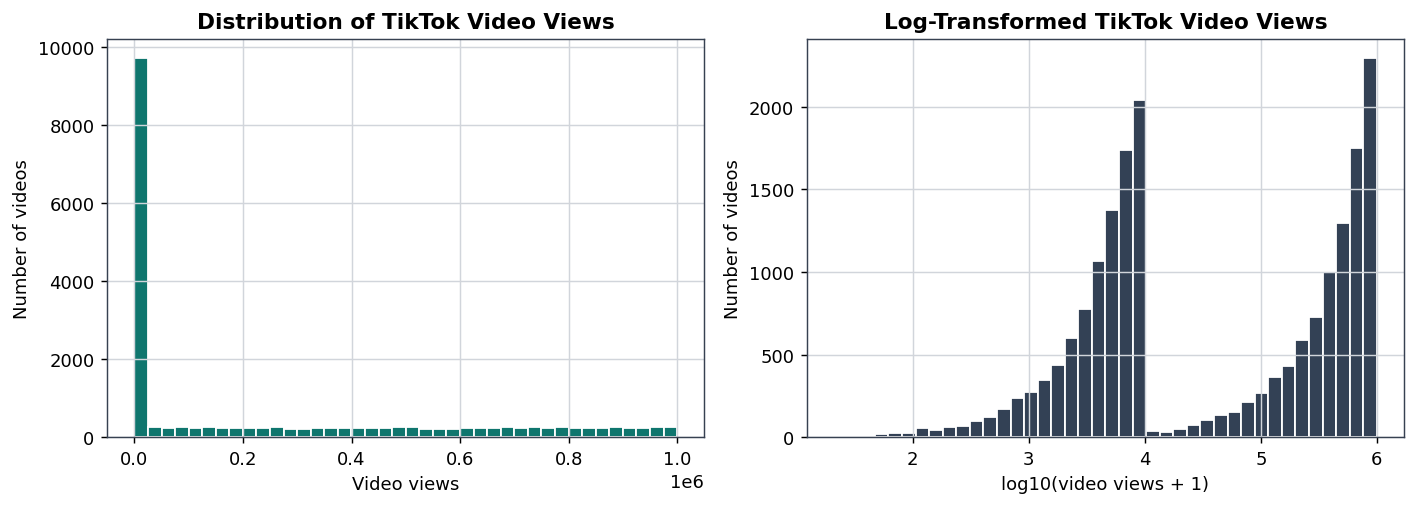

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(tiktok["video_view_count"], bins=40, color=COLORS["TikTok"], edgecolor="white")
axes[0].set_title("Distribution of TikTok Video Views")
axes[0].set_xlabel("Video views")
axes[0].set_ylabel("Number of videos")

log_views = np.log10(tiktok["video_view_count"] + 1)
axes[1].hist(log_views, bins=40, color=COLORS["Neutral"], edgecolor="white")
axes[1].set_title("Log-Transformed TikTok Video Views")
axes[1].set_xlabel("log10(video views + 1)")
axes[1].set_ylabel("Number of videos")

plt.tight_layout()
plt.savefig(FIG_DIR / "tiktok_view_distributions.png", bbox_inches="tight")
plt.show()

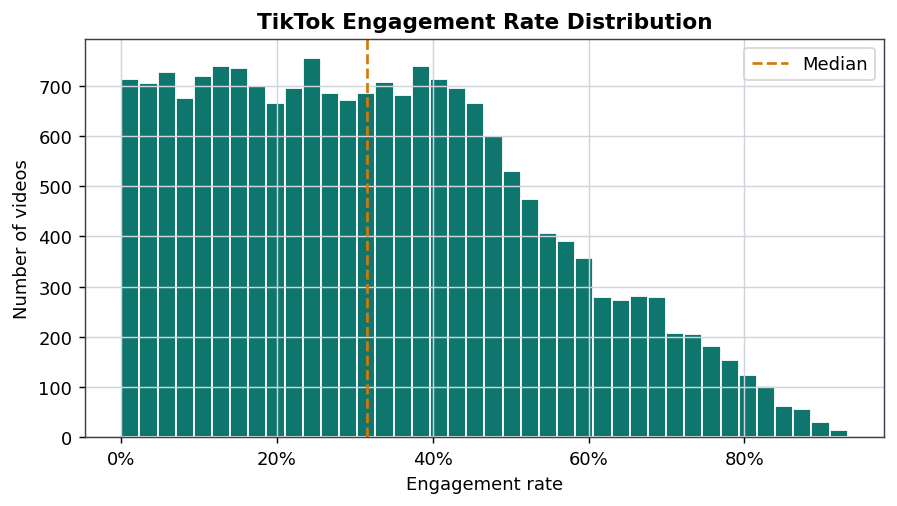

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tiktok["engagement_rate"], bins=40, color=COLORS["TikTok"], edgecolor="white")
ax.axvline(tiktok["engagement_rate"].median(), color=COLORS["Snapchat"], linestyle="--", label="Median")
ax.set_title("TikTok Engagement Rate Distribution")
ax.set_xlabel("Engagement rate")
ax.set_ylabel("Number of videos")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "tiktok_engagement_rate_distribution.png", bbox_inches="tight")
plt.show()

In [12]:
usage_metrics = [
    "Daily_Minutes_Spent", "Posts_Per_Day",
    "Likes_Per_Day", "Follows_Per_Day",
]

usage_summary = (
    usage.groupby("App")[usage_metrics]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)
usage_summary.columns = [f"{metric}_{stat}" for metric, stat in usage_summary.columns]
usage_summary = usage_summary.reset_index()

usage_summary.to_csv(TABLE_DIR / "tiktok_snapchat_usage_summary.csv", index=False)
usage_summary

,App,Daily_Minutes_Spent_mean,Daily_Minutes_Spent_median,Daily_Minutes_Spent_std,Daily_Minutes_Spent_count,Posts_Per_Day_mean,Posts_Per_Day_median,Posts_Per_Day_std,Posts_Per_Day_count,Likes_Per_Day_mean,Likes_Per_Day_median,Likes_Per_Day_std,Likes_Per_Day_count,Follows_Per_Day_mean,Follows_Per_Day_median,Follows_Per_Day_std,Follows_Per_Day_count
0,Snapchat,256.55,274.5,145.55,156,10.00,9.5,6.19,156,93.82,92.5,60.04,156,25.51,26.5,14.94,156
1,TikTok,233.42,219.0,145.42,141,9.56,9.0,6.32,141,91.41,90.0,57.69,141,24.44,23.0,15.03,141


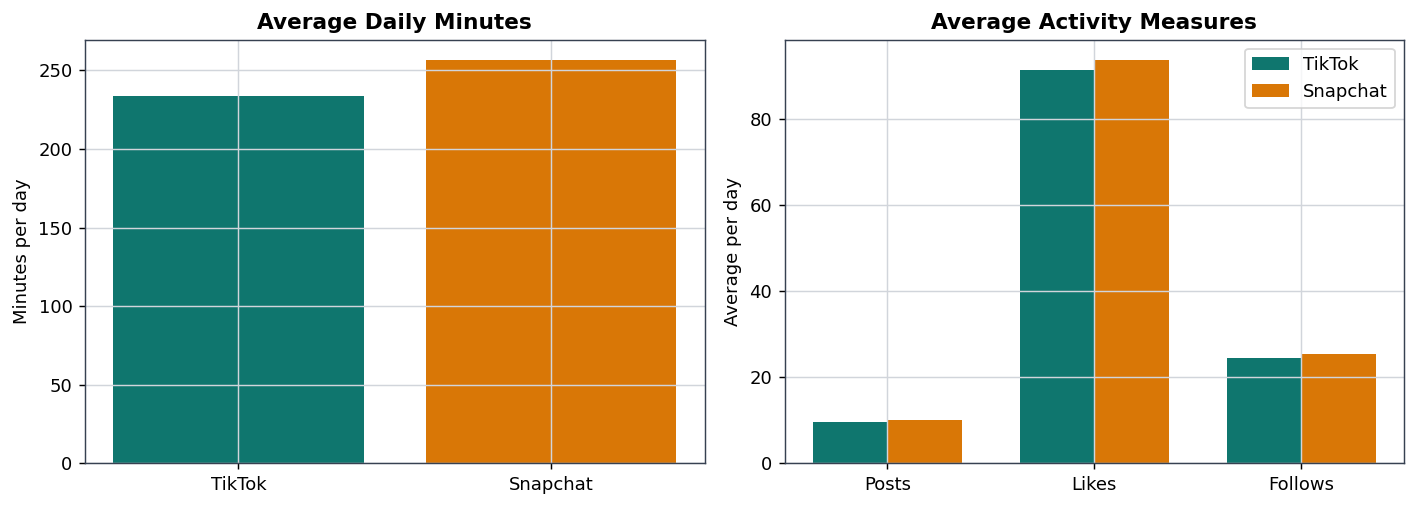

In [13]:
usage_means = usage.groupby("App")[usage_metrics].mean().reindex(["TikTok", "Snapchat"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(usage_means.index, usage_means["Daily_Minutes_Spent"], color=[COLORS["TikTok"], COLORS["Snapchat"]])
axes[0].set_title("Average Daily Minutes")
axes[0].set_ylabel("Minutes per day")

activity_metrics = ["Posts_Per_Day", "Likes_Per_Day", "Follows_Per_Day"]
x = np.arange(len(activity_metrics))
width = 0.36
axes[1].bar(x - width / 2, usage_means.loc["TikTok", activity_metrics], width, label="TikTok", color=COLORS["TikTok"])
axes[1].bar(x + width / 2, usage_means.loc["Snapchat", activity_metrics], width, label="Snapchat", color=COLORS["Snapchat"])
axes[1].set_title("Average Activity Measures")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Posts", "Likes", "Follows"])
axes[1].set_ylabel("Average per day")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "usage_comparison_overview.png", bbox_inches="tight")
plt.show()

## 6. Statistical and Comparative Analysis

Welch t-tests compare TikTok and Snapchat averages. The tests are descriptive evidence only; the data is not a verified representative market sample.

In [14]:
from scipy import stats


def significance_label(p_value):
    if p_value < 0.001:
        return "*** p < .001"
    if p_value < 0.01:
        return "** p < .01"
    if p_value < 0.05:
        return "* p < .05"
    return "Not significant"


ttest_rows = []
for metric in usage_metrics:
    tiktok_values = usage.loc[usage["App"].eq("TikTok"), metric]
    snapchat_values = usage.loc[usage["App"].eq("Snapchat"), metric]
    t_stat, p_value = stats.ttest_ind(tiktok_values, snapchat_values, equal_var=False)

    ttest_rows.append({
        "metric": metric,
        "tiktok_n": len(tiktok_values),
        "snapchat_n": len(snapchat_values),
        "tiktok_mean": tiktok_values.mean(),
        "snapchat_mean": snapchat_values.mean(),
        "mean_difference_tiktok_minus_snapchat": tiktok_values.mean() - snapchat_values.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "significance": significance_label(p_value),
    })

usage_ttests = pd.DataFrame(ttest_rows)
usage_ttests.to_csv(TABLE_DIR / "tiktok_snapchat_independent_ttests.csv", index=False)
usage_ttests

,metric,tiktok_n,snapchat_n,tiktok_mean,snapchat_mean,mean_difference_tiktok_minus_snapchat,t_statistic,p_value,significance
0,Daily_Minutes_Spent,141,156,233.418440,256.551282,-23.132842,-1.368417,0.172233,Not significant
1,Posts_Per_Day,141,156,9.560284,10.000000,-0.439716,-0.604617,0.545905,Not significant
2,Likes_Per_Day,141,156,91.411348,93.820513,-2.409165,-0.352470,0.724738,Not significant
3,Follows_Per_Day,141,156,24.439716,25.506410,-1.066694,-0.612581,0.540631,Not significant


In [15]:
usage_correlation = usage[usage_metrics].corr()
usage_correlation.to_csv(TABLE_DIR / "social_media_usage_correlation_matrix.csv")
usage_correlation

,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
Daily_Minutes_Spent,1.000000,-0.027347,-0.004462,0.070740
Posts_Per_Day,-0.027347,1.000000,-0.008934,0.121385
Likes_Per_Day,-0.004462,-0.008934,1.000000,-0.114255
Follows_Per_Day,0.070740,0.121385,-0.114255,1.000000


## 7. TikTok Engagement Analysis

Engagement rate equals `(likes + shares + comments) / views`. Because likes, shares, comments, and views mathematically define the rate, they are not used as independent predictors of engagement rate. The analysis instead compares engagement rate across independent categorical variables in the TikTok dataset.

In [16]:
group_columns = ["claim_status", "verified_status", "author_ban_status"]

group_summaries = []
for column in group_columns:
    summary = (
        tiktok.groupby(column)
        .agg(
            sample_size=("engagement_rate", "size"),
            mean_engagement_rate=("engagement_rate", "mean"),
            median_engagement_rate=("engagement_rate", "median"),
            mean_download_rate=("download_rate", "mean"),
            mean_views=("video_view_count", "mean"),
            mean_duration_sec=("video_duration_sec", "mean"),
        )
        .reset_index()
        .rename(columns={column: "group"})
    )
    summary.insert(0, "variable", column)
    group_summaries.append(summary)

tiktok_group_summary = pd.concat(group_summaries, ignore_index=True)
tiktok_group_summary.to_csv(TABLE_DIR / "tiktok_independent_group_summary.csv", index=False)
tiktok_group_summary

,variable,group,sample_size,mean_engagement_rate,median_engagement_rate,mean_download_rate,mean_views,mean_duration_sec
0,claim_status,claim,9608,0.398863,0.393634,0.004145,501029.452748,32.486886
1,claim_status,opinion,9476,0.264017,0.259227,0.002713,4956.432250,32.359856
2,verified_status,not verified,17884,0.334781,0.318466,0.003468,265663.785339,32.467345
3,verified_status,verified,1200,0.289071,0.280192,0.002925,91439.164167,31.775000
4,author_ban_status,active,15383,0.320503,0.304730,0.003319,215927.039524,32.550933
5,author_ban_status,banned,1635,0.394381,0.395963,0.004041,445845.439144,32.323547
6,author_ban_status,under review,2066,0.367377,0.350917,0.003813,392204.836399,31.556631


In [17]:
claim_values = [
    values["engagement_rate"].to_numpy()
    for _, values in tiktok.groupby("claim_status")
]
t_stat, p_value = stats.ttest_ind(*claim_values, equal_var=False)

claim_ttest = pd.DataFrame([{
    "comparison": "claim vs opinion",
    "t_statistic": t_stat,
    "p_value": p_value,
    "significance": significance_label(p_value),
}])

claim_ttest.to_csv(TABLE_DIR / "tiktok_claim_status_engagement_ttest.csv", index=False)
claim_ttest

,comparison,t_statistic,p_value,significance
0,claim vs opinion,46.699502,0.0,*** p < .001


In [18]:
verified = tiktok.loc[tiktok["verified_status"].eq("verified"), "engagement_rate"]
not_verified = tiktok.loc[tiktok["verified_status"].eq("not verified"), "engagement_rate"]
t_stat, p_value = stats.ttest_ind(verified, not_verified, equal_var=False)

verified_ttest = pd.DataFrame([{
    "comparison": "verified vs not verified",
    "verified_n": len(verified),
    "not_verified_n": len(not_verified),
    "verified_mean_engagement_rate": verified.mean(),
    "not_verified_mean_engagement_rate": not_verified.mean(),
    "mean_difference": verified.mean() - not_verified.mean(),
    "t_statistic": t_stat,
    "p_value": p_value,
    "significance": significance_label(p_value),
}])

verified_ttest.to_csv(TABLE_DIR / "tiktok_verified_engagement_ttest.csv", index=False)
verified_ttest

,comparison,verified_n,not_verified_n,verified_mean_engagement_rate,not_verified_mean_engagement_rate,mean_difference,t_statistic,p_value,significance
0,verified vs not verified,1200,17884,0.289071,0.334781,-0.045709,-8.654836,1.289772e-17,*** p < .001


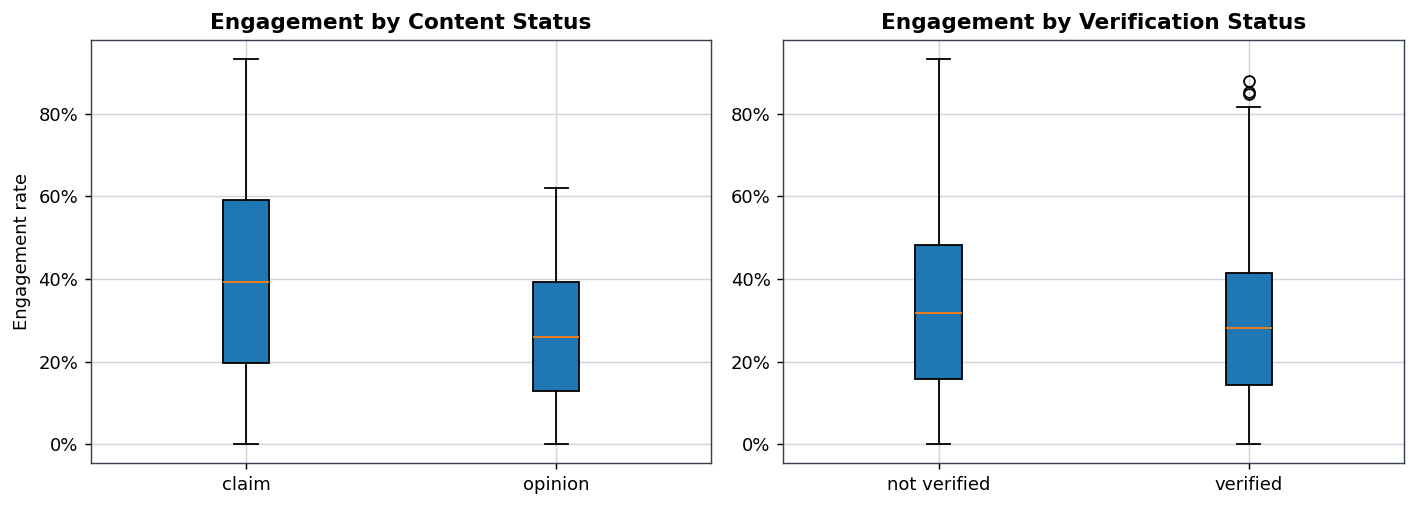

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

claim_groups = [
    tiktok.loc[tiktok["claim_status"].eq(status), "engagement_rate"]
    for status in ["claim", "opinion"]
]
axes[0].boxplot(claim_groups, patch_artist=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["claim", "opinion"])
axes[0].set_title("Engagement by Content Status")
axes[0].set_ylabel("Engagement rate")
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

verified_groups = [
    tiktok.loc[tiktok["verified_status"].eq(status), "engagement_rate"]
    for status in ["not verified", "verified"]
]
axes[1].boxplot(verified_groups, patch_artist=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["not verified", "verified"])
axes[1].set_title("Engagement by Verification Status")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

plt.tight_layout()
plt.savefig(FIG_DIR / "tiktok_engagement_group_comparison.png", bbox_inches="tight")
plt.show()

In [20]:
ban_groups = [
    values["engagement_rate"].to_numpy()
    for _, values in tiktok.groupby("author_ban_status")
]
f_stat, p_value = stats.f_oneway(*ban_groups)

ban_anova = pd.DataFrame([{
    "comparison": "author_ban_status groups",
    "f_statistic": f_stat,
    "p_value": p_value,
    "significance": significance_label(p_value),
}])

ban_anova.to_csv(TABLE_DIR / "tiktok_author_ban_status_engagement_anova.csv", index=False)
ban_anova

,comparison,f_statistic,p_value,significance
0,author_ban_status groups,124.883283,1.305515e-54,*** p < .001


In [21]:
rate_correlation_rows = []
for metric in ["video_duration_sec", "download_rate"]:
    r_value, p_value = stats.pearsonr(tiktok[metric], tiktok["engagement_rate"])
    rate_correlation_rows.append({
        "relationship": f"{metric} vs engagement_rate",
        "pearson_r": r_value,
        "p_value": p_value,
        "significance": significance_label(p_value),
    })

tiktok_rate_correlations = pd.DataFrame(rate_correlation_rows)
tiktok_rate_correlations.to_csv(TABLE_DIR / "tiktok_non_circular_engagement_tests.csv", index=False)
tiktok_rate_correlations

,relationship,pearson_r,p_value,significance
0,video_duration_sec vs engagement_rate,0.01016,0.160489,Not significant
1,download_rate vs engagement_rate,0.66648,0.000000,*** p < .001


In [22]:
tiktok["engagement_segment"] = pd.qcut(
    tiktok["engagement_rate"],
    q=[0, 0.25, 0.75, 1],
    labels=["Low engagement", "Middle engagement", "High engagement"],
)

segment_summary = (
    tiktok.groupby("engagement_segment", observed=True)
    .agg(
        sample_size=("engagement_rate", "size"),
        average_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
        average_views=("video_view_count", "mean"),
        average_likes=("video_like_count", "mean"),
        average_shares=("video_share_count", "mean"),
        average_comments=("video_comment_count", "mean"),
        verified_share=("verified_status", lambda x: x.eq("verified").mean()),
        average_video_duration_sec=("video_duration_sec", "mean"),
    )
    .reset_index()
)

segment_summary.to_csv(TABLE_DIR / "tiktok_engagement_segment_summary.csv", index=False)
tiktok.to_csv(CLEAN_DIR / "tiktok_cleaned_with_segments.csv", index=False)
segment_summary

,engagement_segment,sample_size,average_engagement_rate,median_engagement_rate,average_views,average_likes,average_shares,average_comments,verified_share,average_video_duration_sec
0,Low engagement,4771,0.078367,0.078389,202730.553762,13048.294907,2282.850346,56.427374,0.070425,32.371201
1,Middle engagement,9542,0.314785,0.315662,205636.483546,54870.498323,9806.460176,225.479354,0.073779,32.404737
2,High engagement,4771,0.619689,0.597148,404830.713896,214429.252568,45045.222595,889.862503,0.033536,32.514567


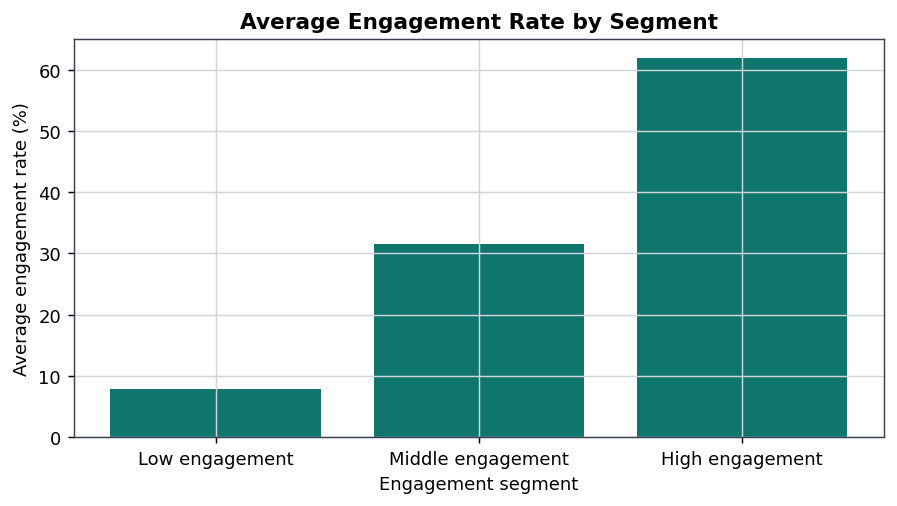

In [23]:
segment_plot = segment_summary.copy()
segment_plot["average_engagement_pct"] = segment_plot["average_engagement_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(segment_plot["engagement_segment"].astype(str), segment_plot["average_engagement_pct"], color=COLORS["TikTok"])
ax.set_title("Average Engagement Rate by Segment")
ax.set_xlabel("Engagement segment")
ax.set_ylabel("Average engagement rate (%)")

plt.tight_layout()
plt.savefig(FIG_DIR / "tiktok_engagement_segments.png", bbox_inches="tight")
plt.show()

## 8. TikTok vs Snapchat Comparison

The shared dataset supports a usage comparison, but it does not include Snapchat video-level engagement, AR usage, revenue, or ad campaign outcomes.

In [24]:
print(f"Clean comparison sample: {len(usage):,} observations")
print(f"Significant mean differences: {(usage_ttests['p_value'] < 0.05).sum()} of {len(usage_ttests)}")

Clean comparison sample: 297 observations
Significant mean differences: 0 of 4


## 9. Business Interpretation

TikTok's business model is interpreted mainly through algorithmic content discovery: video interactions generate signals that can improve recommendations, creator feedback, and advertising inventory. Snapchat is interpreted mainly through communication, habitual friend networks, and augmented reality features. The data supports this strategic distinction conceptually, but only TikTok has content-level measures in the available files.

In [25]:
core_results = {
    "tiktok_videos": len(tiktok),
    "comparison_observations": len(usage),
    "mean_tiktok_engagement_rate": tiktok["engagement_rate"].mean(),
    "median_tiktok_engagement_rate": tiktok["engagement_rate"].median(),
    "significant_usage_tests": int((usage_ttests["p_value"] < 0.05).sum()),
}

core_results

{'tiktok_videos': 19084,
 'comparison_observations': 297,
 'mean_tiktok_engagement_rate': np.float64(0.33190655409918335),
 'median_tiktok_engagement_rate': np.float64(0.31566202627223683),
 'significant_usage_tests': 0}

## 10. Limitations

The TikTok dataset is richer than the Snapchat comparison data. As a result, content-level findings should be presented as TikTok-specific. The project should not claim causal effects, real-world market representativeness, or advertising revenue impact because the datasets do not include experimental design, demographic controls, ad exposure, revenue, conversion, retention, creator category, follower count, watch time, or recommendation-source fields.

## 11. Key Conclusions

- TikTok shows strong video-level engagement patterns, but engagement rate is a constructed metric and should not be predicted using its own components.
- The TikTok-vs-Snapchat usage sample does not show statistically significant mean differences across daily minutes, likes, posts, or follows.
- TikTok's strategic role is best framed around algorithmic content discovery and signal-rich engagement.
- Snapchat's strategic role is best framed around communication, friend networks, and augmented reality.
- The analysis is strongest as a descriptive business analytics project, not as a causal or predictive model.